In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import scipy as sp

In [3]:
G = nx.erdos_renyi_graph(n=100, p=0.05, seed=42)

In [4]:
print("Wierzchołki:", list(G.nodes()))
print("Krawędzie:", list(G.edges()))
print(f"Liczba wierzchołków: {G.number_of_nodes()}")
print(f"Liczba krawędzi: {G.number_of_edges()}")

Wierzchołki: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Krawędzie: [(0, 2), (0, 10), (0, 13), (0, 20), (0, 42), (0, 68), (0, 90), (1, 3), (1, 27), (1, 29), (2, 75), (2, 96), (3, 7), (3, 34), (3, 52), (3, 78), (4, 9), (4, 30), (4, 42), (4, 96), (5, 14), (5, 22), (5, 25), (5, 39), (5, 49), (5, 64), (6, 17), (6, 26), (6, 65), (7, 20), (7, 52), (7, 64), (8, 62), (8, 71), (8, 96), (9, 19), (9, 37), (9, 63), (10, 22), (10, 32), (10, 61), (10, 79), (10, 92), (10, 99), (11, 12), (11, 27), (12, 16), (12, 24), (12, 30), (12, 56), (12, 59), (12, 65), (12, 75), (12, 76), (12, 84), (14, 42), (14, 93), (14, 99), (15, 27), (15, 37), (15, 44), (15, 65), (15, 7

{0: 7, 1: 3, 2: 3, 3: 5, 4: 4, 5: 6, 6: 3, 7: 4, 8: 3, 9: 4, 10: 7, 11: 2, 12: 10, 13: 1, 14: 4, 15: 7, 16: 3, 17: 4, 18: 2, 19: 4, 20: 4, 21: 3, 22: 7, 23: 1, 24: 10, 25: 4, 26: 1, 27: 9, 28: 4, 29: 3, 30: 7, 31: 3, 32: 5, 33: 2, 34: 8, 35: 3, 36: 3, 37: 8, 38: 2, 39: 6, 40: 4, 41: 1, 42: 7, 43: 6, 44: 5, 45: 4, 46: 2, 47: 3, 48: 6, 49: 4, 50: 6, 51: 2, 52: 5, 53: 3, 54: 6, 55: 4, 56: 3, 57: 4, 58: 5, 59: 7, 60: 4, 61: 4, 62: 3, 63: 5, 64: 6, 65: 10, 66: 5, 67: 5, 68: 3, 69: 5, 70: 3, 71: 4, 72: 6, 73: 3, 74: 6, 75: 7, 76: 5, 77: 2, 78: 6, 79: 5, 80: 5, 81: 4, 82: 3, 83: 2, 84: 5, 85: 3, 86: 4, 87: 5, 88: 3, 89: 1, 90: 9, 91: 4, 92: 5, 93: 5, 94: 4, 95: 1, 96: 8, 97: 6, 98: 5, 99: 3}


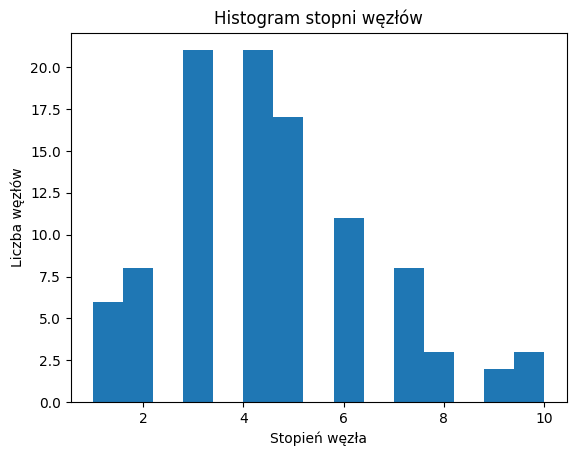

In [5]:
degrees = dict(G.degree())
print(degrees)

plt.hist(list(degrees.values()), bins=15)
plt.xlabel("Stopień węzła")
plt.ylabel("Liczba węzłów")
plt.title("Histogram stopni węzłów")
plt.show()

In [6]:
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)

In [7]:
# Uwaga: average_shortest_path i diameter działają tylko na grafach spójnych!
# Bierzemy największy komponent:
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)

avg_shortest_path = nx.average_shortest_path_length(G_sub)
diameter = nx.diameter(G_sub)
num_components = nx.number_connected_components(G)
density = nx.density(G)

In [10]:
df = pd.DataFrame({
    "betweenness_centrality": betweenness,
    "closeness_centrality": closeness,
    "clustering_coefficient": clustering,
    "pagerank": pagerank,
    "avg_shortest_path": avg_shortest_path,
    "diameter": diameter,
    "num_components": num_components,
    "density": density
})

df.index.name = "node"
df.head(10)

,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,num_components,density
node,,,,,,,,
0,0.057686,0.348592,0.000000,0.015786,3.149697,6,1,0.045253
1,0.005995,0.289474,0.333333,0.007274,3.149697,6,1,0.045253
2,0.006593,0.312303,0.000000,0.007057,3.149697,6,1,0.045253
3,0.027686,0.332215,0.100000,0.010870,3.149697,6,1,0.045253
4,0.009870,0.327815,0.000000,0.008646,3.149697,6,1,0.045253
5,0.028715,0.332215,0.066667,0.012565,3.149697,6,1,0.045253
6,0.023378,0.294643,0.000000,0.008632,3.149697,6,1,0.045253
7,0.012491,0.303681,0.166667,0.009173,3.149697,6,1,0.045253
8,0.007079,0.299094,0.000000,0.007271,3.149697,6,1,0.045253


In [12]:
df.describe()

,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,num_components,density
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.0,100.0,1.000000e+02
mean,0.021936,0.321045,0.042341,0.010000,3.149697e+00,6.0,1.0,4.525253e-02
std,0.021229,0.033182,0.095074,0.003907,1.785306e-15,0.0,0.0,1.394770e-17
min,0.000000,0.228111,0.000000,0.003369,3.149697e+00,6.0,1.0,4.525253e-02
25%,0.007198,0.303681,0.000000,0.007260,3.149697e+00,6.0,1.0,4.525253e-02
50%,0.016789,0.321429,0.000000,0.009203,3.149697e+00,6.0,1.0,4.525253e-02
75%,0.028001,0.342858,0.049603,0.012304,3.149697e+00,6.0,1.0,4.525253e-02
max,0.116356,0.412500,0.666667,0.020749,3.149697e+00,6.0,1.0,4.525253e-02


In [14]:
print(f"Liczba komponentów: {nx.number_connected_components(G)}")

for i, comp in enumerate(nx.connected_components(G)):
    print(f"Komponent {i}: {comp}")

Liczba komponentów: 1
Komponent 0: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99}


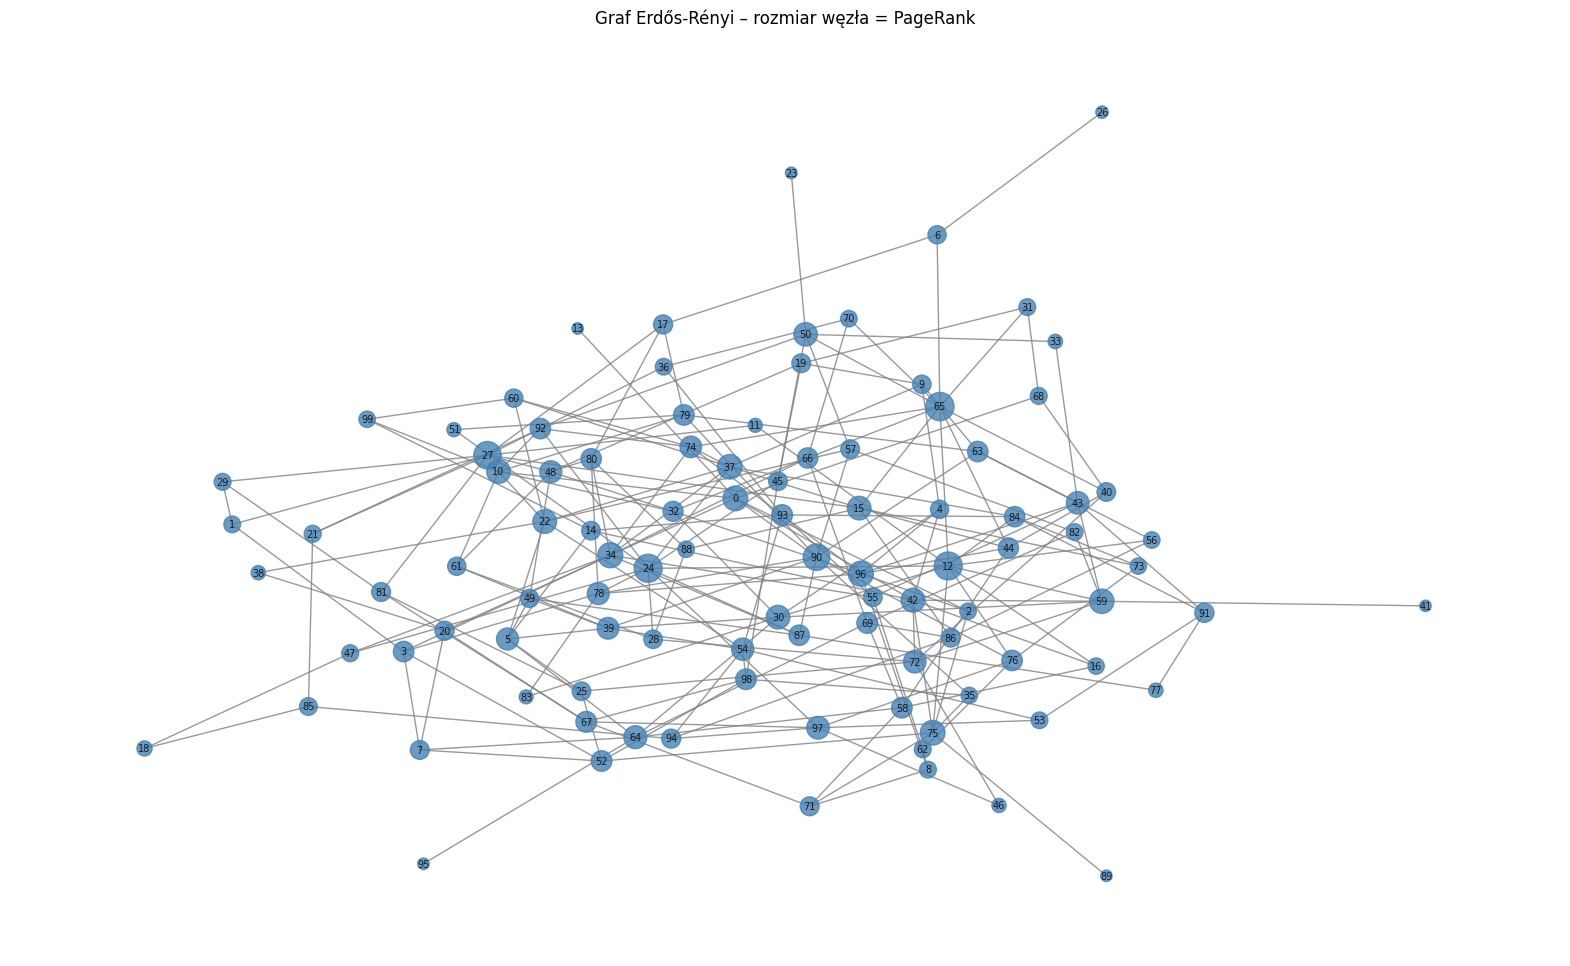

In [17]:
pagerank = nx.pagerank(G)  # już masz to policzone wcześniej

# Skalujemy PageRank do sensownego rozmiaru węzłów
node_sizes = [pagerank[node] * 20000 for node in G.nodes()]

plt.figure(figsize=(20, 12))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color="steelblue",
    edge_color="gray",
    with_labels=True,
    font_size=7,
    alpha=0.8
)

plt.title("Graf Erdős-Rényi – rozmiar węzła = PageRank")
plt.axis("off")
plt.show()

## Punkt 2

In [18]:
G_ba = nx.barabasi_albert_graph(n=1000, m=3, seed=42)

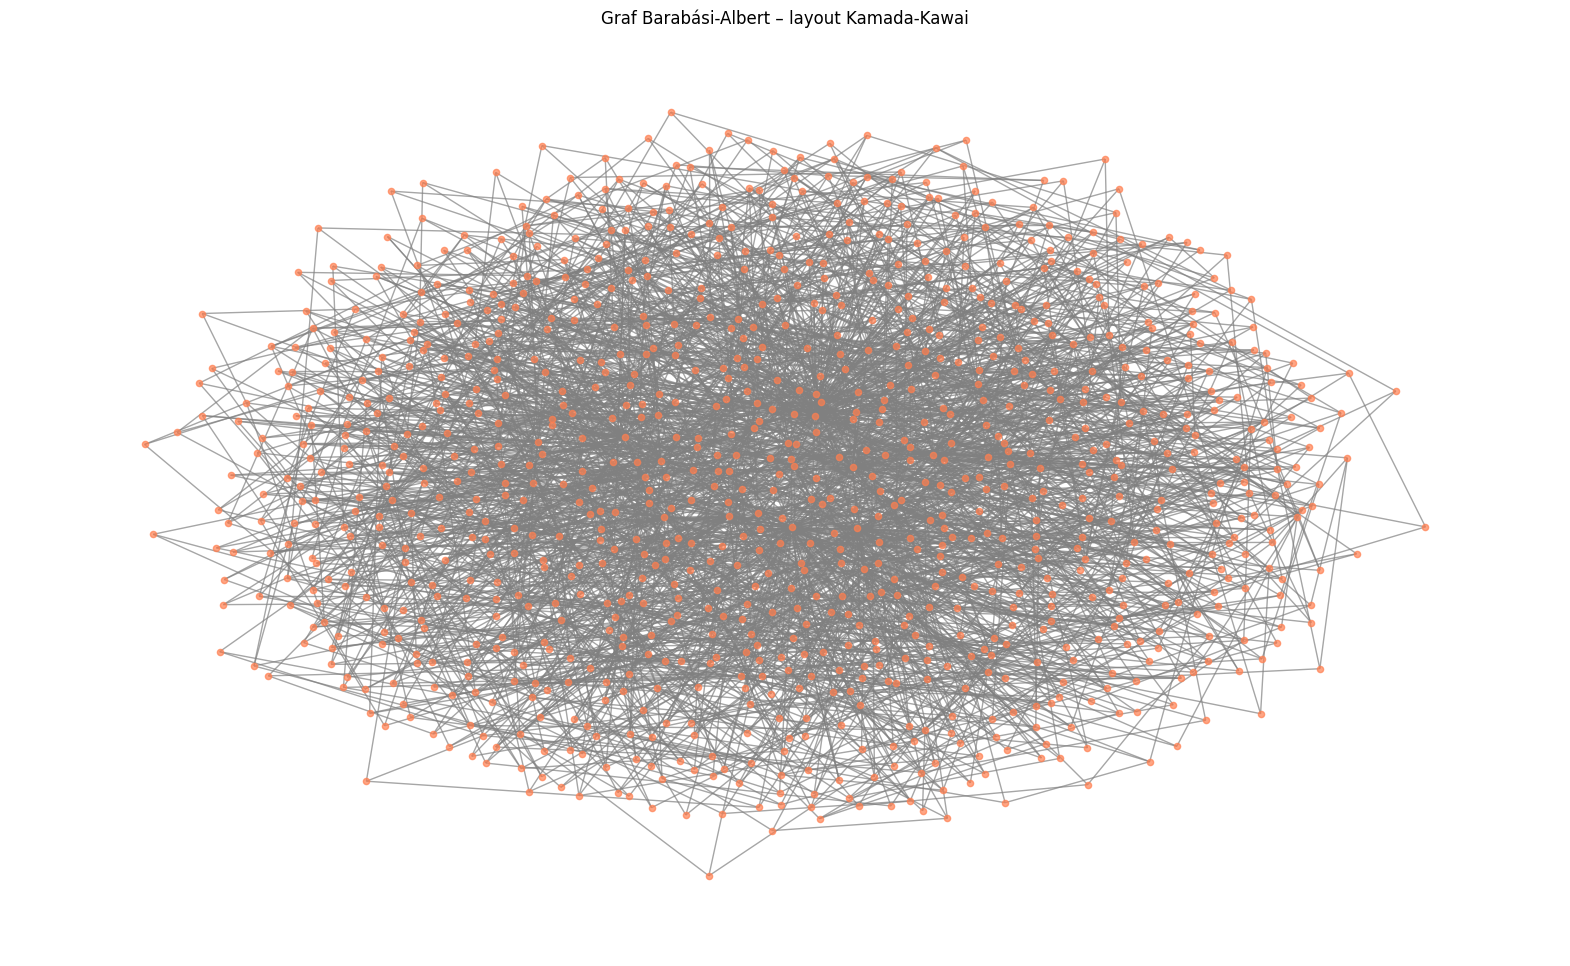

In [22]:
plt.figure(figsize=(20, 12))
pos_kk = nx.kamada_kawai_layout(G_ba)

nx.draw_networkx(
    G_ba,
    pos=pos_kk,
    node_size=20,
    node_color="coral",
    edge_color="gray",
    with_labels=False,
    alpha=0.7
)

plt.title("Graf Barabási-Albert – layout Kamada-Kawai")
plt.axis("off")
plt.show()

In [20]:
betweenness_ba = nx.betweenness_centrality(G_ba)

most_central = max(betweenness_ba, key=betweenness_ba.get)
print(f"Najbardziej centralny węzeł: {most_central}")
print(f"Wartość betweenness: {betweenness_ba[most_central]:.4f}")

Najbardziej centralny węzeł: 4
Wartość betweenness: 0.1513


In [21]:
diameter_ba = nx.diameter(G_ba)
print(f"Średnica grafu BA: {diameter_ba}")

Średnica grafu BA: 6
